### Project Context and Exploration Goals

**Objective:**
To collect logo exposure data by zone, we need to perform frame-by-frame predictions. As observed in previous explorations, the target videos typically last between **9 and 10 minutes**. Consequently, running the model on every single frame (at **30 frames per second**) is computationally expensive and extremely time-consuming.

**Optimization Strategy:**
While code optimizations (such as GPU batch inference and parallel video downloading) and model selection (using lightweight models for faster inference) provide improvements, the **most significant efficiency gain** comes from reducing the **sampling rate** (the number of frames analyzed per second).

**The Trade-off:**
There is an inherent trade-off between **accuracy** (how close the calculated KPIs are to the "Ground Truth" obtained at 30 FPS) and **processing speed**. Lowering the frame rate drastically improves speed but introduces approximations.

**Methodology:**
Prior to this analysis, the inference pipeline was executed using **four** different frame rates to evaluate this trade-off:
*   **30 FPS:** Represents the **Ground Truth** (exact KPIs, no approximation, slow).
*   **10 FPS, 5 FPS & 3 FPS:** Represent **Approximations** (estimated KPIs, significantly faster).

The goal of this notebook is to quantify the error margin of these approximations to determine the best balance between speed and accuracy.

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure the graphics style for a more professional rendering
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

In [2]:
# Loading the data
df_frame_3 = pd.read_csv("Data/exposure_and_game_info/exposure_results_frame_3.csv")
df_frame_5 = pd.read_csv("Data/exposure_and_game_info/exposure_results_frame_5.csv")
df_frame_10 = pd.read_csv("Data/exposure_and_game_info/exposure_results_frame_10.csv")
df_frame_30 = pd.read_csv("Data/exposure_and_game_info/exposure_results_frame_30.csv")

# Renaming columns to identify the frequency (frame rate)
df_frame_3.rename(columns={
    'exposure_time_seconds': "exposure_time_seconds_f3",
    "average_box_area_pixels": "average_box_area_pixels_f3"
}, inplace=True)

df_frame_5.rename(columns={
    'exposure_time_seconds': "exposure_time_seconds_f5",
    "average_box_area_pixels": "average_box_area_pixels_f5"
}, inplace=True)

df_frame_10.rename(columns={
    'exposure_time_seconds': "exposure_time_seconds_f10",
    "average_box_area_pixels": "average_box_area_pixels_f10"
}, inplace=True)

df_frame_30.rename(columns={
    'exposure_time_seconds': "exposure_time_seconds_f30",
    "average_box_area_pixels": "average_box_area_pixels_f30"
}, inplace=True)

# Merging the dataframes
# We merge on video_id and exposure_zone to compare the same elements
df_merge = pd.merge(df_frame_3.drop(columns=['game_id', 'video_url']), 
                    df_frame_5.drop(columns=['game_id', 'video_url']),  
                    on=['video_id', 'exposure_zone'], how='inner')

df_merge = pd.merge(df_merge, 
                    df_frame_10.drop(columns=['game_id', 'video_url']), 
                    on=['video_id', 'exposure_zone'], how='inner')

df_merge = pd.merge(df_merge, 
                    df_frame_30.drop(columns=['game_id', 'video_url']), 
                    on=['video_id', 'exposure_zone'], how='inner')

In [3]:
print(f"Number of videos in the analysis sample: {df_merge['video_id'].nunique()}")

Number of videos in the analysis sample: 23


The sample is small because it takes too much time to run the code for 30 frames but the sample should be enough to have some insigths

In [4]:
# Global view
display(df_merge.describe())

# Detailed statistics by exposure zone for each sampling frequency
print("\n--- Statistics for 3 FPS ---")
display(df_merge.groupby('exposure_zone')[['exposure_time_seconds_f3', 'average_box_area_pixels_f3']].describe())

print("\n--- Statistics for 5 FPS ---")
display(df_merge.groupby('exposure_zone')[['exposure_time_seconds_f5', 'average_box_area_pixels_f5']].describe())

print("\n--- Statistics for 10 FPS ---")
display(df_merge.groupby('exposure_zone')[['exposure_time_seconds_f10', 'average_box_area_pixels_f10']].describe())

print("\n--- Statistics for 30 FPS (Ground Truth) ---")
display(df_merge.groupby('exposure_zone')[['exposure_time_seconds_f30', 'average_box_area_pixels_f30']].describe())

,exposure_time_seconds_f3,average_box_area_pixels_f3,exposure_time_seconds_f5,average_box_area_pixels_f5,exposure_time_seconds_f10,average_box_area_pixels_f10,exposure_time_seconds_f30,average_box_area_pixels_f30
count,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000
mean,374.037565,2460.521391,373.840000,2461.401565,373.763478,2467.434435,373.815565,2468.780261
std,162.341613,1589.298752,162.556744,1572.769436,162.740040,1574.069508,162.695899,1574.792347
min,0.330000,219.510000,0.400000,268.190000,0.300000,319.950000,0.570000,319.830000
25%,288.335000,848.900000,291.100000,847.780000,290.750000,863.450000,290.715000,941.380000
50%,441.670000,2257.350000,440.200000,2263.960000,441.100000,2296.870000,440.900000,2311.650000
75%,484.000000,3570.720000,485.600000,3551.185000,485.150000,3572.085000,485.050000,3538.310000
max,606.670000,6305.250000,608.000000,6283.590000,608.400000,6328.040000,608.500000,6309.930000



--- Statistics for 3 FPS ---


exposure_time_seconds_f3                                  \
                                       count        mean         std     min   
exposure_zone                                                                  
back-court-logo                         23.0  359.710435  176.407031    6.00   
basket-logo                             23.0  462.971304   37.607691  399.67   
mid-court-logo                          23.0  316.173913  157.295609   45.33   
side-court-led-logo                     23.0  411.926957  118.182617  187.00   
side-court-logo                         23.0  319.405217  220.721606    0.33   

                                                       \
                         25%     50%      75%     max   
exposure_zone                                           
back-court-logo      236.170  449.00  484.500  577.67   
basket-logo          442.170  463.67  476.335  577.67   
mid-court-logo       201.665  351.67  469.000  529.33   
side-court-led-logo  339.165  434.33  506.665  606.67   
side-court-logo       19.500  438.33  485.500  553.67   

                    average_box_area_pixels_f3                            \
                                         count         mean          std   
exposure_zone                                                              
back-court-logo                           23.0  3126.456522  1433.083603   
basket-logo                               23.0   520.038696   103.120142   
mid-court-logo                            23.0  3626.486957   862.370599   
side-court-led-logo                       23.0  3378.310000  1465.056053   
side-court-logo                           23.0  1651.314783   864.543357   

                                                                    
                         min       25%      50%       75%      max  
exposure_zone                                                       
back-court-logo      1242.00  1995.910  2801.20  3708.175  6276.12  
basket-logo           319.90   470.335   526.92   562.265   846.22  
mid-court-logo       1724.99  3199.260  3628.52  4051.200  5328.00  
side-court-led-logo  1809.13  2167.765  3042.92  4466.025  6305.25  
side-court-logo       219.51   828.620  2089.25  2244.760  3476.61


--- Statistics for 5 FPS ---


exposure_time_seconds_f5                                 \
                                       count        mean         std    min   
exposure_zone                                                                 
back-court-logo                         23.0  358.965217  177.232879    7.2   
basket-logo                             23.0  462.669565   37.749924  399.0   
mid-court-logo                          23.0  316.286957  157.306982   44.2   
side-court-led-logo                     23.0  411.678261  118.382458  184.8   
side-court-logo                         23.0  319.600000  220.942107    0.4   

                                                average_box_area_pixels_f5  \
                       25%    50%    75%    max                      count   
exposure_zone                                                                
back-court-logo      236.5  448.8  485.8  576.0                       23.0   
basket-logo          441.2  461.2  477.7  578.4                       23.0   
mid-court-logo       201.8  352.2  470.0  530.0                       23.0   
side-court-led-logo  338.9  432.8  505.6  608.0                       23.0   
side-court-logo       18.5  435.4  487.2  553.8                       23.0   

                                                                           \
                            mean          std      min       25%      50%   
exposure_zone                                                               
back-court-logo      3130.467391  1425.815449  1253.61  1984.320  2803.01   
basket-logo           519.931304   103.487131   319.84   471.025   527.35   
mid-court-logo       3625.453043   854.453414  1724.08  3267.165  3615.80   
side-court-led-logo  3358.309130  1426.237725  1805.68  2242.830  2906.65   
side-court-logo      1672.846957   832.782019   268.19   842.750  2084.69   

                                        
                          75%      max  
exposure_zone                           
back-court-logo      3702.780  6283.59  
basket-logo           562.665   848.93  
mid-court-logo       4053.280  5309.33  
side-court-led-logo  4419.090  6052.56  
side-court-logo      2242.495  3466.29


--- Statistics for 10 FPS ---


exposure_time_seconds_f10                                 \
                                        count        mean         std    min   
exposure_zone                                                                  
back-court-logo                          23.0  359.208696  177.180586    7.9   
basket-logo                              23.0  462.660870   37.680568  399.8   
mid-court-logo                           23.0  315.821739  157.547638   44.0   
side-court-led-logo                      23.0  411.495652  119.061014  183.1   
side-court-logo                          23.0  319.630435  221.092896    0.3   

                                                 average_box_area_pixels_f10  \
                       25%    50%     75%    max                       count   
exposure_zone                                                                  
back-court-logo      236.8  448.3  485.15  576.3                        23.0   
basket-logo          441.5  461.3  477.00  578.0                        23.0   
mid-court-logo       194.6  352.4  469.70  530.1                        23.0   
side-court-led-logo  339.1  433.9  505.70  608.4                        23.0   
side-court-logo       18.5  439.1  487.25  553.3                        23.0   

                                                                           \
                            mean          std      min       25%      50%   
exposure_zone                                                               
back-court-logo      3131.100000  1435.047674  1258.73  1966.225  2805.92   
basket-logo           520.391739   103.505491   319.95   471.005   527.28   
mid-court-logo       3632.334348   856.366605  1722.17  3234.990  3648.13   
side-court-led-logo  3371.716087  1421.718795  1805.84  2261.585  3004.96   
side-court-logo      1681.630000   819.360559   372.99   863.450  2084.23   

                                        
                          75%      max  
exposure_zone                           
back-court-logo      3724.020  6328.04  
basket-logo           562.885   849.16  
mid-court-logo       4053.430  5309.10  
side-court-led-logo  4430.490  6219.61  
side-court-logo      2245.295  3472.39


--- Statistics for 30 FPS (Ground Truth) ---


exposure_time_seconds_f30                                  \
                                        count        mean         std     min   
exposure_zone                                                                   
back-court-logo                          23.0  358.949565  177.493492    7.50   
basket-logo                              23.0  462.683043   37.660676  400.30   
mid-court-logo                           23.0  316.086522  157.245624   44.33   
side-court-led-logo                      23.0  411.671304  118.590191  183.67   
side-court-logo                          23.0  319.687391  221.173255    0.57   

                                                       \
                         25%     50%      75%     max   
exposure_zone                                           
back-court-logo      236.000  448.17  485.050  576.37   
basket-logo          441.415  460.57  477.000  578.07   
mid-court-logo       200.135  351.90  469.400  530.77   
side-court-led-logo  339.220  432.83  505.650  608.50   
side-court-logo       18.700  439.13  487.035  553.30   

                    average_box_area_pixels_f30                            \
                                          count         mean          std   
exposure_zone                                                               
back-court-logo                            23.0  3130.820000  1430.720225   
basket-logo                                23.0   520.473043   103.843978   
mid-court-logo                             23.0  3629.441739   855.984849   
side-court-led-logo                        23.0  3373.997826  1438.590896   
side-court-logo                            23.0  1689.168696   814.643930   

                                                                    
                         min       25%      50%       75%      max  
exposure_zone                                                       
back-court-logo      1263.09  1970.705  2803.07  3709.820  6309.93  
basket-logo           319.83   471.475   526.91   563.160   850.80  
mid-court-logo       1727.07  3285.115  3671.67  4051.910  5314.39  
side-court-led-logo  1808.35  2270.965  2941.95  4438.170  6175.18  
side-court-logo       329.44   941.380  2083.22  2245.025  3479.57

In [5]:
# Calculation of differences compare to reality (30fps)
# If the result is positive, the approximation underestimates. If negative, it overestimates.

# Comparison 3 FPS vs 30 FPS
df_merge['exposure_time_diff_3_30'] = df_merge['exposure_time_seconds_f30'] - df_merge['exposure_time_seconds_f3']
df_merge['average_box_area_diff_3_30'] = df_merge['average_box_area_pixels_f30'] - df_merge['average_box_area_pixels_f3']

# Comparison 5 FPS vs 30 FPS
df_merge['exposure_time_diff_5_30'] = df_merge['exposure_time_seconds_f30'] - df_merge['exposure_time_seconds_f5']
df_merge['average_box_area_diff_5_30'] = df_merge['average_box_area_pixels_f30'] - df_merge['average_box_area_pixels_f5']

# Comparison 10 FPS vs 30 FPS
df_merge['exposure_time_diff_10_30'] = df_merge['exposure_time_seconds_f30'] - df_merge['exposure_time_seconds_f10']
df_merge['average_box_area_diff_10_30'] = df_merge['average_box_area_pixels_f30'] - df_merge['average_box_area_pixels_f10']

# Display of difference statistics
display(df_merge[['exposure_time_diff_3_30', 'average_box_area_diff_3_30', 
                  'exposure_time_diff_5_30', 'average_box_area_diff_5_30',
                  'exposure_time_diff_10_30', 'average_box_area_diff_10_30']].describe())

print("\n--- Detail of differences (3 FPS vs 30 FPS) by zone ---")
display(df_merge.groupby('exposure_zone')[['exposure_time_diff_3_30', 'average_box_area_diff_3_30']].describe())

print("\n--- Detail of differences (5 FPS vs 30 FPS) by zone ---")
display(df_merge.groupby('exposure_zone')[['exposure_time_diff_5_30', 'average_box_area_diff_5_30']].describe())

print("\n--- Detail of differences (10 FPS vs 30 FPS) by zone ---")
display(df_merge.groupby('exposure_zone')[['exposure_time_diff_10_30', 'average_box_area_diff_10_30']].describe())

,exposure_time_diff_3_30,average_box_area_diff_3_30,exposure_time_diff_5_30,average_box_area_diff_5_30,exposure_time_diff_10_30,average_box_area_diff_10_30
count,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000
mean,-0.222000,8.258870,-0.024435,7.378696,0.052087,1.345826
std,1.708383,85.604409,1.028099,36.196883,1.458211,34.229193
min,-6.500000,-362.720000,-4.800000,-147.970000,-2.570000,-126.220000
25%,-0.895000,-7.265000,-0.615000,-0.555000,-0.400000,-2.160000
50%,-0.140000,-0.010000,-0.100000,1.000000,-0.030000,0.070000
75%,0.480000,4.725000,0.500000,7.525000,0.250000,3.450000
max,5.060000,705.120000,3.730000,182.670000,11.270000,243.010000



--- Detail of differences (3 FPS vs 30 FPS) by zone ---


exposure_time_diff_3_30                                   \
                                      count      mean       std   min    25%   
exposure_zone                                                                  
back-court-logo                        23.0 -0.760870  2.504122 -6.50 -1.430   
basket-logo                            23.0 -0.288261  1.139384 -3.90 -0.530   
mid-court-logo                         23.0 -0.087391  1.591512 -3.27 -0.815   
side-court-led-logo                    23.0 -0.255652  1.463777 -3.33 -1.365   
side-court-logo                        23.0  0.282174  1.511655 -2.77 -0.405   

                                       average_box_area_diff_3_30             \
                      50%    75%   max                      count       mean   
exposure_zone                                                                  
back-court-logo     -0.47  0.400  5.06                       23.0   4.363478   
basket-logo          0.10  0.290  1.20                       23.0   0.434348   
mid-court-logo      -0.30  0.545  4.10                       23.0   2.954783   
side-court-led-logo -0.10  0.785  2.44                       23.0  -4.312174   
side-court-logo      0.24  0.885  3.53                       23.0  37.853913   

                                                                       
                            std     min     25%   50%     75%     max  
exposure_zone                                                          
back-court-logo       21.431000  -37.22  -7.320  0.29   8.775   63.24  
basket-logo            1.247717   -1.44  -0.335  0.18   1.070    4.58  
mid-court-logo        47.811523 -120.94  -7.445 -3.20   8.980  122.47  
side-court-led-logo  108.903636 -362.72 -31.370 -7.42  30.120  239.98  
side-court-logo      148.916070  -47.09  -2.650  0.58   5.695  705.12


--- Detail of differences (5 FPS vs 30 FPS) by zone ---


exposure_time_diff_5_30                                   \
                                      count      mean       std   min    25%   
exposure_zone                                                                  
back-court-logo                        23.0 -0.015652  0.882779 -1.97 -0.700   
basket-logo                            23.0  0.013478  0.677332 -0.80 -0.615   
mid-court-logo                         23.0 -0.200435  1.029026 -2.90 -0.635   
side-court-led-logo                    23.0 -0.006957  0.789916 -1.67 -0.600   
side-court-logo                        23.0  0.087391  1.583926 -4.80 -0.450   

                                       average_box_area_diff_5_30             \
                      50%    75%   max                      count       mean   
exposure_zone                                                                  
back-court-logo     -0.17  0.565  1.50                       23.0   0.352609   
basket-logo         -0.23  0.515  1.30                       23.0   0.541739   
mid-court-logo      -0.30  0.330  2.23                       23.0   3.988696   
side-court-led-logo -0.03  0.430  1.60                       23.0  15.688696   
side-court-logo     -0.03  0.850  3.73                       23.0  16.321739   

                                                                      
                           std     min    25%    50%     75%     max  
exposure_zone                                                         
back-court-logo      12.147945  -31.90 -2.665   1.75   5.575   26.34  
basket-logo           0.837663   -0.45 -0.020   0.30   0.790    2.67  
mid-court-logo       21.695341  -51.16 -5.095   0.40   6.490   56.59  
side-court-led-logo  63.641825 -147.97  2.410  12.25  33.830  175.51  
side-court-logo      43.031934  -20.81 -0.680   1.39   4.420  182.67


--- Detail of differences (10 FPS vs 30 FPS) by zone ---


exposure_time_diff_10_30                                   \
                                       count      mean       std   min    25%   
exposure_zone                                                                   
back-court-logo                         23.0 -0.259130  0.808528 -2.57 -0.465   
basket-logo                             23.0  0.022174  0.425547 -0.73 -0.250   
mid-court-logo                          23.0  0.264783  2.522221 -1.97 -0.585   
side-court-led-logo                     23.0  0.175652  1.439677 -1.23 -0.320   
side-court-logo                         23.0  0.056957  1.258554 -1.90 -0.285   

                                        average_box_area_diff_10_30            \
                      50%    75%    max                       count      mean   
exposure_zone                                                                   
back-court-logo     -0.17  0.115   1.20                        23.0 -0.280000   
basket-logo          0.00  0.370   0.90                        23.0  0.081304   
mid-court-logo      -0.17  0.280  11.27                        23.0 -2.892609   
side-court-led-logo  0.07  0.315   6.30                        23.0  2.281739   
side-court-logo     -0.03  0.235   4.97                        23.0  7.538696   

                                                                     
                           std     min    25%   50%     75%     max  
exposure_zone                                                        
back-court-logo      10.746512  -34.34 -1.755  0.32   3.405   17.52  
basket-logo           0.730792   -2.14 -0.215 -0.01   0.350    1.64  
mid-court-logo       33.418282 -126.22 -2.940  0.77   5.095   50.50  
side-court-led-logo  44.286592  -97.13 -7.500  2.51  10.625  125.69  
side-court-logo      53.036602  -53.57 -2.375 -0.56   1.345  243.01

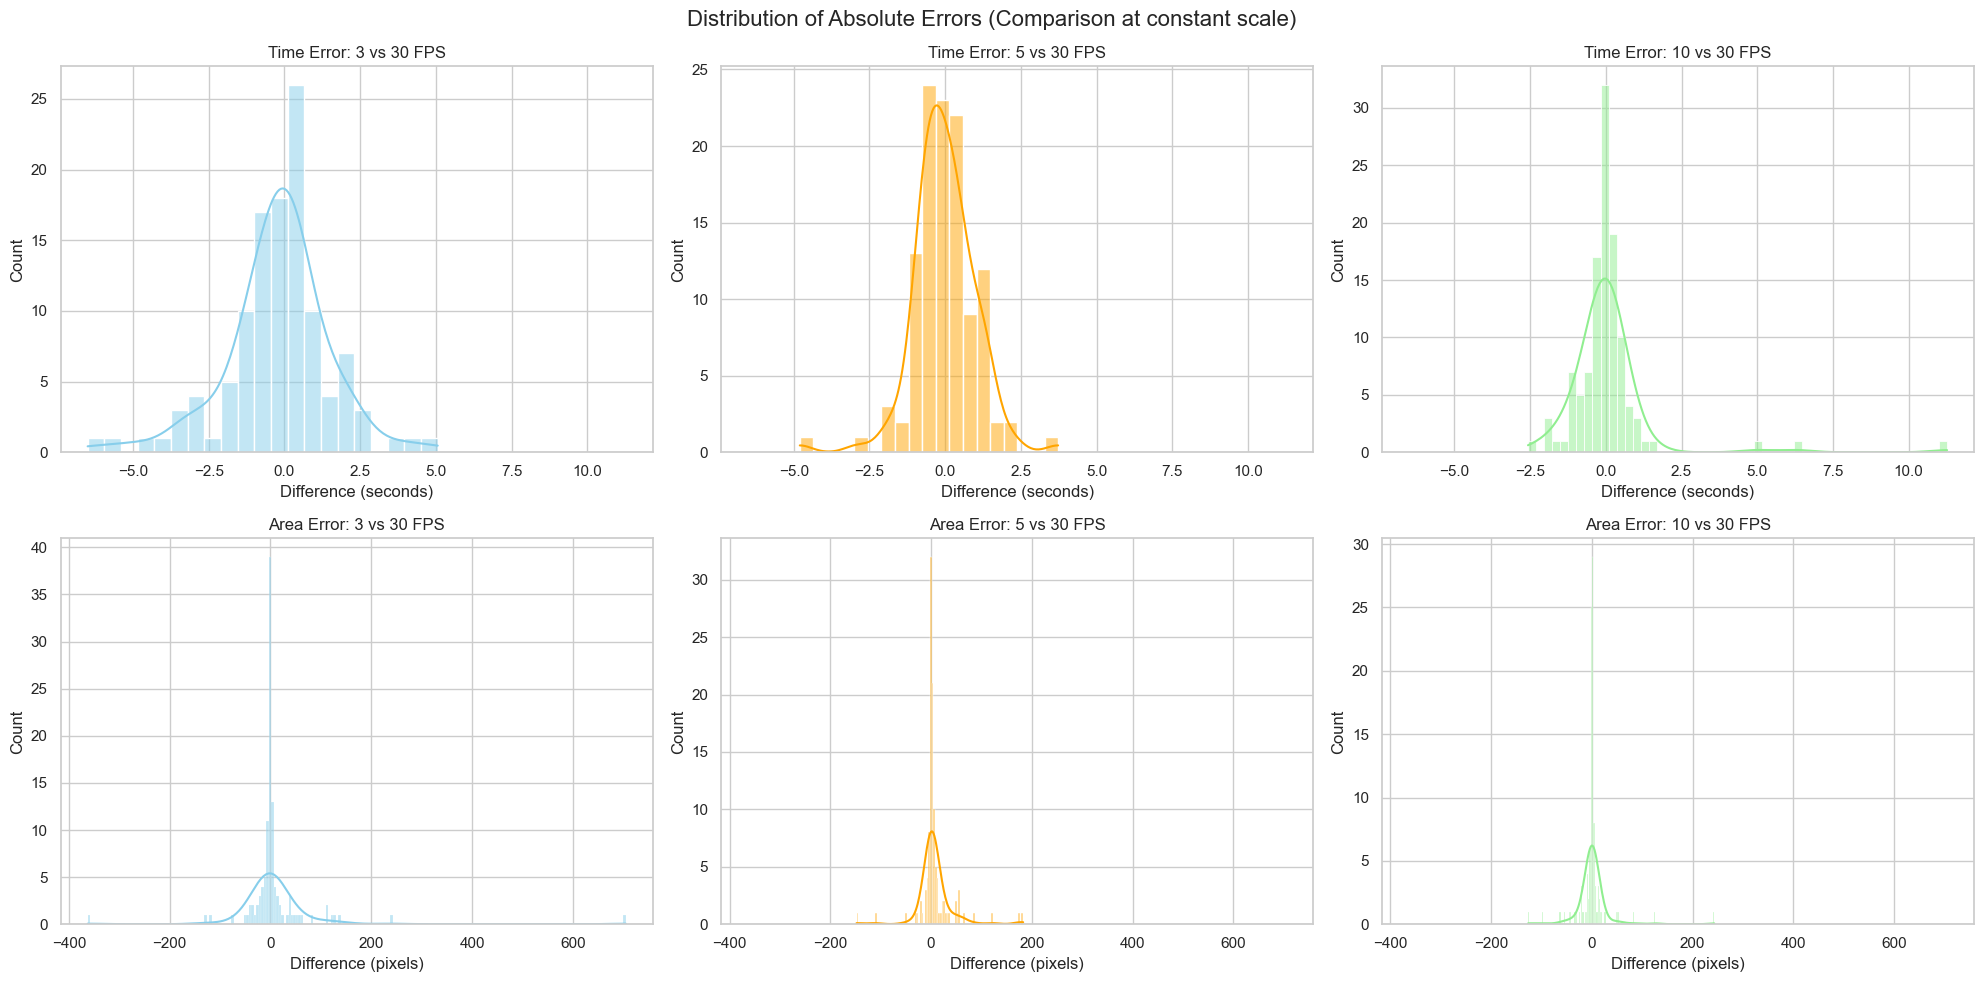

In [6]:
# 1. Definition of common limits for the X axis
# For time (Second): we include 3, 5 and 10 fps
time_min = min(df_merge["exposure_time_diff_5_30"].min(), 
               df_merge["exposure_time_diff_3_30"].min(), 
               df_merge["exposure_time_diff_10_30"].min())

time_max = max(df_merge["exposure_time_diff_5_30"].max(), 
               df_merge["exposure_time_diff_3_30"].max(), 
               df_merge["exposure_time_diff_10_30"].max())

# 5% margin
time_margin = (time_max - time_min) * 0.05
time_xlim = (time_min - time_margin, time_max + time_margin)

# For area (Pixels): we include 3, 5 and 10 fps
area_min = min(df_merge["average_box_area_diff_5_30"].min(), 
               df_merge["average_box_area_diff_3_30"].min(), 
               df_merge["average_box_area_diff_10_30"].min())

area_max = max(df_merge["average_box_area_diff_5_30"].max(), 
               df_merge["average_box_area_diff_3_30"].max(), 
               df_merge["average_box_area_diff_10_30"].max())

# 5% margin
area_margin = (area_max - area_min) * 0.05
area_xlim = (area_min - area_margin, area_max + area_margin)


# 2. Creation of graphs (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(20, 10)) # I widened the figure a bit (20, 10)
fig.suptitle("Distribution of Absolute Errors (Comparison at constant scale)", fontsize=16)

# --- Row 1: Exposure time ---

# 5 FPS vs 30 FPS (Column 0)
sns.histplot(df_merge["exposure_time_diff_3_30"], kde=True, ax=axes[0, 0], color="skyblue")
axes[0, 0].set_title("Time Error: 3 vs 30 FPS")
axes[0, 0].set_xlabel("Difference (seconds)")
axes[0, 0].set_xlim(time_xlim)

# 3 FPS vs 30 FPS (Column 1)
sns.histplot(df_merge["exposure_time_diff_5_30"], kde=True, ax=axes[0, 1], color="orange")
axes[0, 1].set_title("Time Error: 5 vs 30 FPS")
axes[0, 1].set_xlabel("Difference (seconds)")
axes[0, 1].set_xlim(time_xlim)

# 10 FPS vs 30 FPS (Column 2) - NEW
sns.histplot(df_merge["exposure_time_diff_10_30"], kde=True, ax=axes[0, 2], color="lightgreen")
axes[0, 2].set_title("Time Error: 10 vs 30 FPS")
axes[0, 2].set_xlabel("Difference (seconds)")
axes[0, 2].set_xlim(time_xlim)


# --- Row 2: Average Area ---

# 5 FPS vs 30 FPS (Column 0)
sns.histplot(df_merge["average_box_area_diff_3_30"], kde=True, ax=axes[1, 0], color="skyblue")
axes[1, 0].set_title("Area Error: 3 vs 30 FPS")
axes[1, 0].set_xlabel("Difference (pixels)")
axes[1, 0].set_xlim(area_xlim)

# 3 FPS vs 30 FPS (Column 1)
sns.histplot(df_merge["average_box_area_diff_5_30"], kde=True, ax=axes[1, 1], color="orange")
axes[1, 1].set_title("Area Error: 5 vs 30 FPS")
axes[1, 1].set_xlabel("Difference (pixels)")
axes[1, 1].set_xlim(area_xlim)

# 10 FPS vs 30 FPS (Column 2) - NEW
sns.histplot(df_merge["average_box_area_diff_10_30"], kde=True, ax=axes[1, 2], color="lightgreen")
axes[1, 2].set_title("Area Error: 10 vs 30 FPS")
axes[1, 2].set_xlabel("Difference (pixels)")
axes[1, 2].set_xlim(area_xlim)

plt.tight_layout()
plt.show()

C:\Users\Kyliv\AppData\Local\Temp\ipykernel_154688\2211686479.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merge, x='exposure_zone', y='exposure_time_diff_3_30', ax=axes[0, 0], palette="Oranges")
C:\Users\Kyliv\AppData\Local\Temp\ipykernel_154688\2211686479.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merge, x='exposure_zone', y='exposure_time_diff_5_30', ax=axes[0, 1], palette="Blues")
C:\Users\Kyliv\AppData\Local\Temp\ipykernel_154688\2211686479.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_me

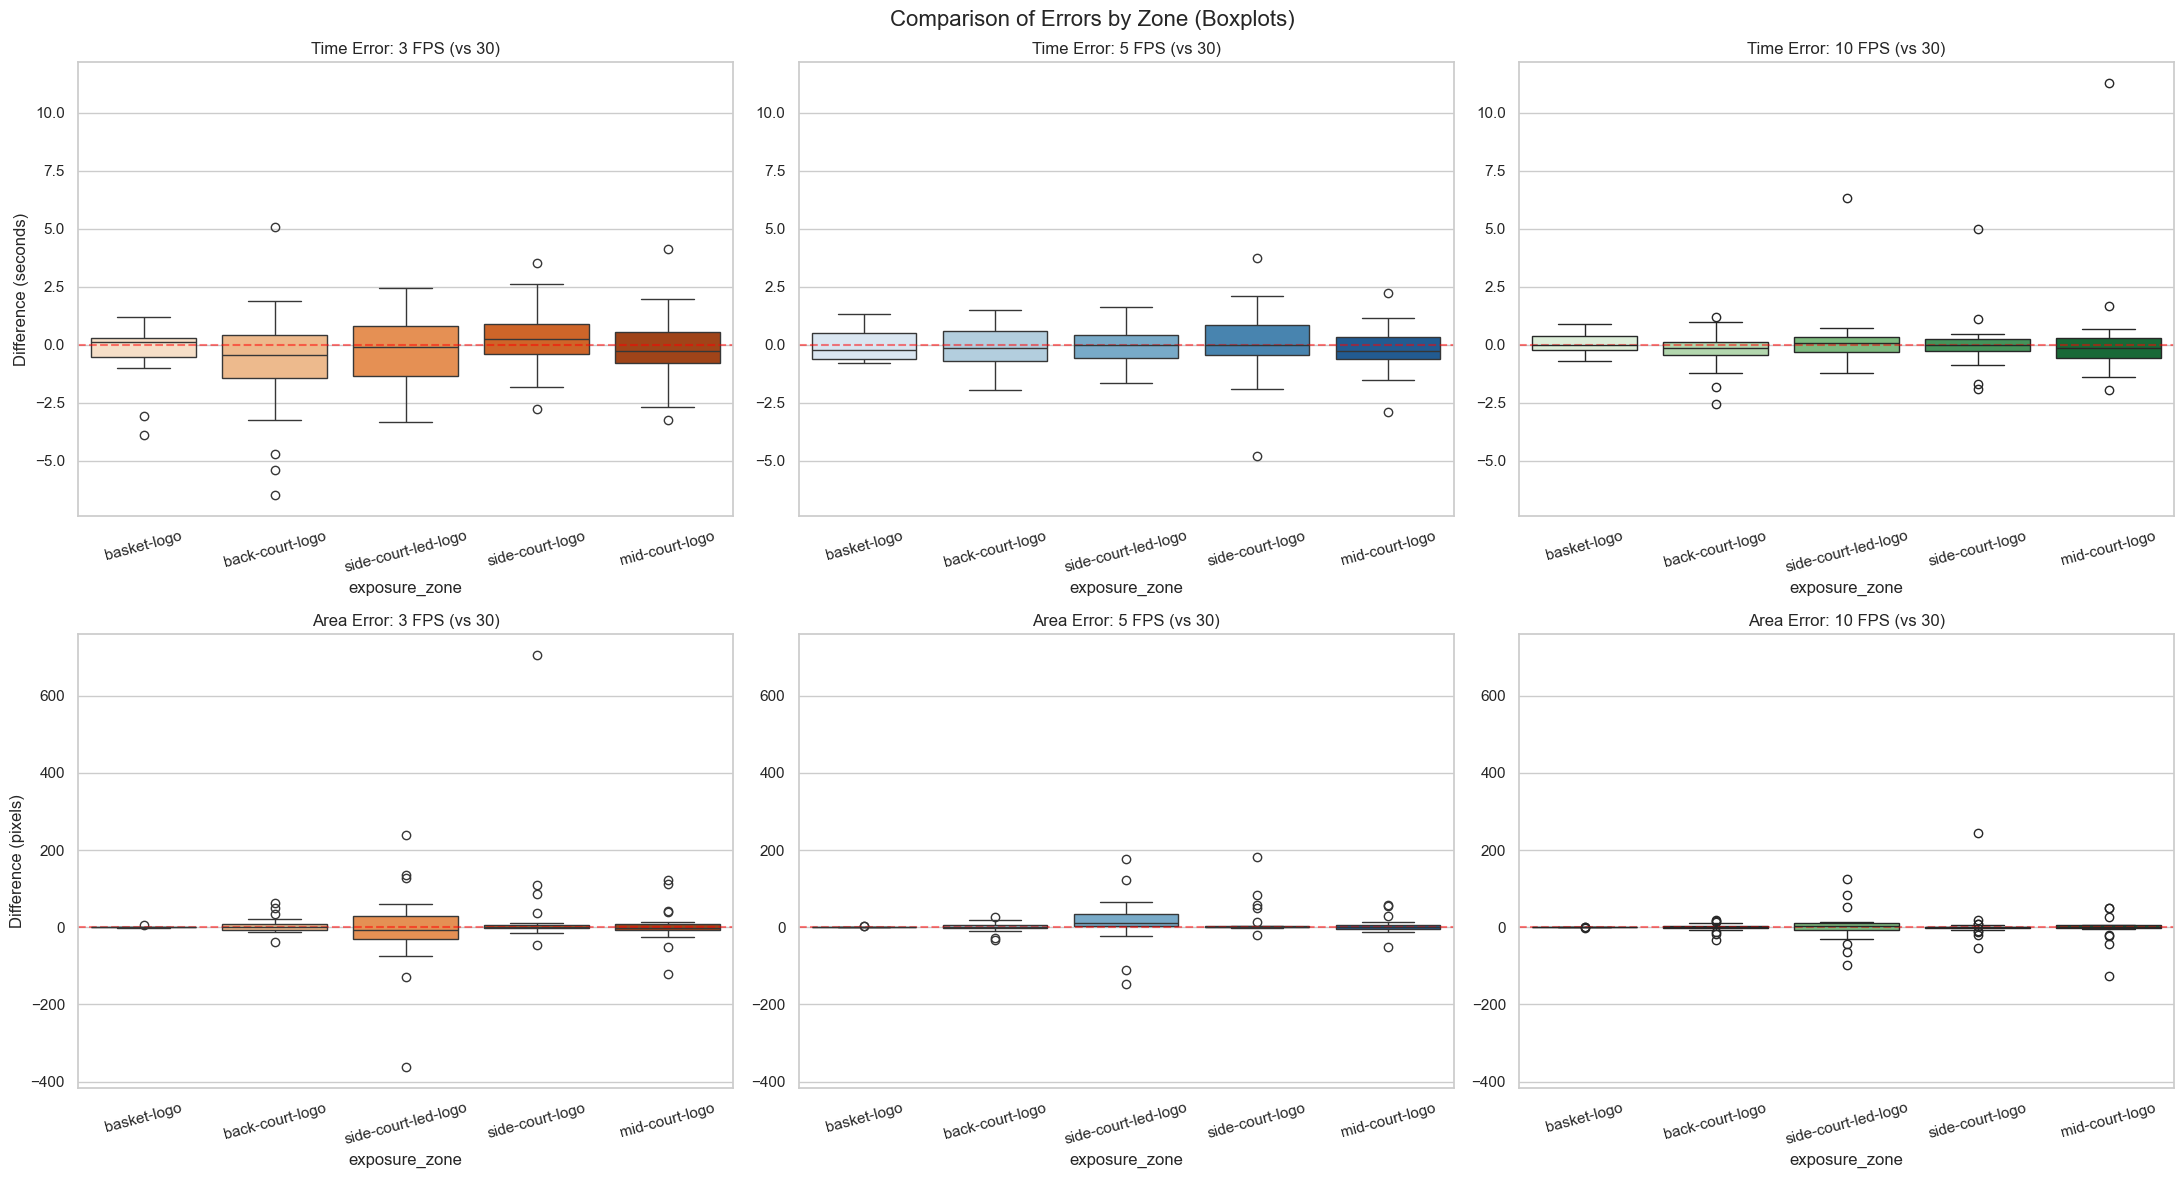

In [7]:
# 1. Calculation of common limits for the Y axis (to include 3, 5 and 10 FPS)
# Time
y_time_min = min(df_merge["exposure_time_diff_3_30"].min(), 
                 df_merge["exposure_time_diff_5_30"].min(), 
                 df_merge["exposure_time_diff_10_30"].min())

y_time_max = max(df_merge["exposure_time_diff_3_30"].max(), 
                 df_merge["exposure_time_diff_5_30"].max(), 
                 df_merge["exposure_time_diff_10_30"].max())

# 5% margin
y_time_lim = (y_time_min - (y_time_max-y_time_min)*0.05, y_time_max + (y_time_max-y_time_min)*0.05)

# Area
y_area_min = min(df_merge["average_box_area_diff_3_30"].min(), 
                 df_merge["average_box_area_diff_5_30"].min(), 
                 df_merge["average_box_area_diff_10_30"].min())

y_area_max = max(df_merge["average_box_area_diff_3_30"].max(), 
                 df_merge["average_box_area_diff_5_30"].max(), 
                 df_merge["average_box_area_diff_10_30"].max())

# 5% margin
y_area_lim = (y_area_min - (y_area_max-y_area_min)*0.05, y_area_max + (y_area_max-y_area_min)*0.05)


# 2. Creation of the figure and axes (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(22, 12)) # Widened figure for 3 columns
fig.suptitle("Comparison of Errors by Zone (Boxplots)", fontsize=16)

# --- Row 1: Exposure time ---

# 3 FPS
sns.boxplot(data=df_merge, x='exposure_zone', y='exposure_time_diff_3_30', ax=axes[0, 0], palette="Oranges")
axes[0, 0].set_title("Time Error: 3 FPS (vs 30)")
axes[0, 0].set_ylabel("Difference (seconds)")
axes[0, 0].set_ylim(y_time_lim)
axes[0, 0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0, 0].tick_params(axis='x', rotation=15)

# 5 FPS
sns.boxplot(data=df_merge, x='exposure_zone', y='exposure_time_diff_5_30', ax=axes[0, 1], palette="Blues")
axes[0, 1].set_title("Time Error: 5 FPS (vs 30)")
axes[0, 1].set_ylabel("")
axes[0, 1].set_ylim(y_time_lim)
axes[0, 1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0, 1].tick_params(axis='x', rotation=15)

# 10 FPS (NEW)
sns.boxplot(data=df_merge, x='exposure_zone', y='exposure_time_diff_10_30', ax=axes[0, 2], palette="Greens")
axes[0, 2].set_title("Time Error: 10 FPS (vs 30)")
axes[0, 2].set_ylabel("")
axes[0, 2].set_ylim(y_time_lim)
axes[0, 2].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0, 2].tick_params(axis='x', rotation=15)


# --- Row 2: Average Area ---

# 3 FPS
sns.boxplot(data=df_merge, x='exposure_zone', y='average_box_area_diff_3_30', ax=axes[1, 0], palette="Oranges")
axes[1, 0].set_title("Area Error: 3 FPS (vs 30)")
axes[1, 0].set_ylabel("Difference (pixels)")
axes[1, 0].set_ylim(y_area_lim)
axes[1, 0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1, 0].tick_params(axis='x', rotation=15)

# 5 FPS
sns.boxplot(data=df_merge, x='exposure_zone', y='average_box_area_diff_5_30', ax=axes[1, 1], palette="Blues")
axes[1, 1].set_title("Area Error: 5 FPS (vs 30)")
axes[1, 1].set_ylabel("")
axes[1, 1].set_ylim(y_area_lim)
axes[1, 1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1, 1].tick_params(axis='x', rotation=15)

# 10 FPS (NEW)
sns.boxplot(data=df_merge, x='exposure_zone', y='average_box_area_diff_10_30', ax=axes[1, 2], palette="Greens")
axes[1, 2].set_title("Area Error: 10 FPS (vs 30)")
axes[1, 2].set_ylabel("")
axes[1, 2].set_ylim(y_area_lim)
axes[1, 2].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1, 2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [8]:
# Calcul des pourcentages d'erreur (Erreur Relative)
# Formule : (Valeur_Approchée - Valeur_Réelle) / Valeur_Réelle * 100
# Résultat négatif = Sous-estimation | Résultat positif = Sur-estimation

# --- Calcul pour 3 FPS ---
df_merge['exposure_time_pct_error_3'] = (
    (df_merge['exposure_time_seconds_f3'] - df_merge['exposure_time_seconds_f30']) / df_merge['exposure_time_seconds_f30']
) * 100

df_merge['average_area_pct_error_3'] = (
    (df_merge['average_box_area_pixels_f3'] - df_merge['average_box_area_pixels_f30']) / df_merge['average_box_area_pixels_f30']
) * 100

# --- Calcul pour 5 FPS ---
df_merge['exposure_time_pct_error_5'] = (
    (df_merge['exposure_time_seconds_f5'] - df_merge['exposure_time_seconds_f30']) / df_merge['exposure_time_seconds_f30']
) * 100

df_merge['average_area_pct_error_5'] = (
    (df_merge['average_box_area_pixels_f5'] - df_merge['average_box_area_pixels_f30']) / df_merge['average_box_area_pixels_f30']
) * 100

# --- Calcul pour 10 FPS ---
df_merge['exposure_time_pct_error_10'] = (
    (df_merge['exposure_time_seconds_f10'] - df_merge['exposure_time_seconds_f30']) / df_merge['exposure_time_seconds_f30']
) * 100

df_merge['average_area_pct_error_10'] = (
    (df_merge['average_box_area_pixels_f10'] - df_merge['average_box_area_pixels_f30']) / df_merge['average_box_area_pixels_f30']
) * 100


# Affichage des statistiques descriptives des erreurs en pourcentage
print("--- Statistiques globales de l'erreur en pourcentage (3, 5 et 10 FPS) ---")
cols_to_describe = [
    'exposure_time_pct_error_3', 'average_area_pct_error_3', 
    'exposure_time_pct_error_5', 'average_area_pct_error_5',
    'exposure_time_pct_error_10', 'average_area_pct_error_10'
]
display(df_merge[cols_to_describe].describe())

print("\n--- Détail de l'erreur en pourcentage par zone : 3 FPS ---")
display(df_merge.groupby('exposure_zone')[['exposure_time_pct_error_3', 
                                           'average_area_pct_error_3']].describe())

print("\n--- Détail de l'erreur en pourcentage par zone : 5 FPS ---")
display(df_merge.groupby('exposure_zone')[['exposure_time_pct_error_5', 
                                           'average_area_pct_error_5']].describe())

print("\n--- Détail de l'erreur en pourcentage par zone : 10 FPS ---")
display(df_merge.groupby('exposure_zone')[['exposure_time_pct_error_10', 
                                           'average_area_pct_error_10']].describe())

--- Statistiques globales de l'erreur en pourcentage (3, 5 et 10 FPS) ---


,exposure_time_pct_error_3,average_area_pct_error_3,exposure_time_pct_error_5,average_area_pct_error_5,exposure_time_pct_error_10,average_area_pct_error_10
count,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000
mean,-0.803622,-1.117826,-0.391062,-0.658928,-0.187707,0.002289
std,8.338257,7.492490,5.221232,3.327136,5.436687,2.864093
min,-50.746269,-69.025197,-40.298507,-23.954405,-47.368421,-23.788594
25%,-0.156016,-0.281357,-0.146700,-0.328749,-0.078886,-0.140283
50%,0.037820,0.001898,0.039276,-0.082735,0.006130,-0.006184
75%,0.240888,0.215759,0.170212,0.062237,0.103162,0.091567
max,34.817814,12.329237,21.457490,4.633027,29.554656,16.260928



--- Détail de l'erreur en pourcentage par zone : 3 FPS ---


exposure_time_pct_error_3                                  \
                                        count      mean        std        min   
exposure_zone                                                                   
back-court-logo                          23.0  0.076837   4.857632 -20.000000   
basket-logo                              23.0  0.063213   0.247020  -0.251467   
mid-court-logo                           23.0 -0.105315   1.853282  -7.869482   
side-court-led-logo                      23.0  0.117443   0.492132  -0.507519   
side-court-logo                          23.0 -4.170286  17.835276 -50.746269   

                                                              \
                          25%       50%       75%        max   
exposure_zone                                                  
back-court-logo     -0.088099  0.090641  0.297942   6.446494   
basket-logo         -0.058797 -0.023729  0.115980   0.843371   
mid-court-logo      -0.169394  0.103199  0.253823   2.255809   
side-court-led-logo -0.160572  0.053126  0.268492   1.813034   
side-court-logo     -0.553343 -0.164904  0.245678  34.817814   

                    average_area_pct_error_3                                  \
                                       count      mean        std        min   
exposure_zone                                                                  
back-court-logo                         23.0 -0.287455   1.302420  -4.325108   
basket-logo                             23.0 -0.066000   0.200827  -0.538317   
mid-court-logo                          23.0 -0.112325   1.414232  -3.887443   
side-court-led-logo                     23.0 -0.150790   3.835250 -10.055646   
side-court-logo                         23.0 -4.972559  15.906021 -69.025197   

                                                              
                          25%       50%       75%        max  
exposure_zone                                                 
back-court-logo     -0.264788 -0.008129  0.183143   1.919556  
basket-logo         -0.194817 -0.046264  0.061451   0.300138  
mid-court-logo      -0.213725  0.085647  0.181576   3.536433  
side-court-led-logo -1.331569  0.231470  1.038270  12.329237  
side-court-logo     -0.316699 -0.040303  0.140498   6.207733


--- Détail de l'erreur en pourcentage par zone : 5 FPS ---


exposure_time_pct_error_5                                  \
                                        count      mean        std        min   
exposure_zone                                                                   
back-court-logo                          23.0 -0.044066   1.008702  -4.000000   
basket-logo                              23.0 -0.004564   0.149943  -0.324756   
mid-court-logo                           23.0  0.039125   0.558903  -1.533384   
side-court-led-logo                      23.0  0.022688   0.220921  -0.338784   
side-court-logo                          23.0 -1.968492  11.687853 -40.298507   

                                                              \
                          25%       50%       75%        max   
exposure_zone                                                  
back-court-logo     -0.155023  0.061096  0.182787   1.953784   
basket-logo         -0.113286  0.045765  0.131260   0.172712   
mid-court-logo      -0.109498  0.085251  0.256350   1.298701   
side-court-led-logo -0.089411  0.005644  0.152257   0.615234   
side-court-logo     -0.257161  0.039331  0.335634  21.457490   

                    average_area_pct_error_5                                 \
                                       count      mean       std        min   
exposure_zone                                                                 
back-court-logo                         23.0  0.061803  0.619223  -0.750540   
basket-logo                             23.0 -0.095804  0.153840  -0.571001   
mid-court-logo                          23.0 -0.101514  0.591477  -1.521651   
side-court-led-logo                     23.0 -0.418495  1.654933  -2.862950   
side-court-logo                         23.0 -2.740628  6.933672 -23.954405   

                                                             
                          25%       50%       75%       max  
exposure_zone                                                
back-court-logo     -0.149011 -0.060786  0.082022  2.226767  
basket-logo         -0.153445 -0.065930  0.004690  0.090755  
mid-court-logo      -0.188519 -0.010754  0.158407  1.439217  
side-court-led-logo -0.966919 -0.463294 -0.103210  4.633027  
side-court-logo     -0.295305 -0.081968  0.032851  2.810833


--- Détail de l'erreur en pourcentage par zone : 10 FPS ---


exposure_time_pct_error_10                       \
                                         count      mean        std   
exposure_zone                                                         
back-court-logo                           23.0  0.417109   1.307723   
basket-logo                               23.0 -0.005286   0.094097   
mid-court-logo                            23.0 -0.038643   1.576613   
side-court-led-logo                       23.0 -0.090281   0.489107   
side-court-logo                           23.0 -1.221436  12.130559   

                                                                         \
                           min       25%       50%       75%        max   
exposure_zone                                                             
back-court-logo      -1.477082 -0.024863  0.035049  0.187545   5.333333   
basket-logo          -0.203252 -0.077690  0.000000  0.053922   0.158499   
mid-court-logo       -6.368311 -0.081840  0.032104  0.198866   2.687140   
side-court-led-logo  -2.239602 -0.104640 -0.015903  0.085844   0.255840   
side-court-logo     -47.368421 -0.156241  0.012662  0.159431  29.554656   

                    average_area_pct_error_10                                 \
                                        count      mean       std        min   
exposure_zone                                                                  
back-court-logo                          23.0 -0.060930  0.452800  -1.222977   
basket-logo                              23.0 -0.006172  0.133786  -0.257821   
mid-court-logo                           23.0  0.076735  0.963502  -1.579165   
side-court-led-logo                      23.0  0.103457  1.242738  -2.203526   
side-court-logo                          23.0 -0.101646  6.307052 -23.788594   

                                                              
                          25%       50%       75%        max  
exposure_zone                                                 
back-court-logo     -0.119794 -0.008325  0.074491   0.903558  
basket-logo         -0.066201  0.002062  0.044546   0.457656  
mid-court-logo      -0.108734 -0.025057  0.115353   3.583851  
side-court-led-logo -0.336372 -0.068269  0.260851   4.068034  
side-court-logo     -0.092369  0.031015  0.099381  16.260928

C:\Users\Kyliv\AppData\Local\Temp\ipykernel_154688\581121179.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merge, x='exposure_zone', y='exposure_time_pct_error_3', ax=axes[0, 0], palette="Oranges")
C:\Users\Kyliv\AppData\Local\Temp\ipykernel_154688\581121179.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merge, x='exposure_zone', y='exposure_time_pct_error_5', ax=axes[0, 1], palette="Blues")
C:\Users\Kyliv\AppData\Local\Temp\ipykernel_154688\581121179.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_m

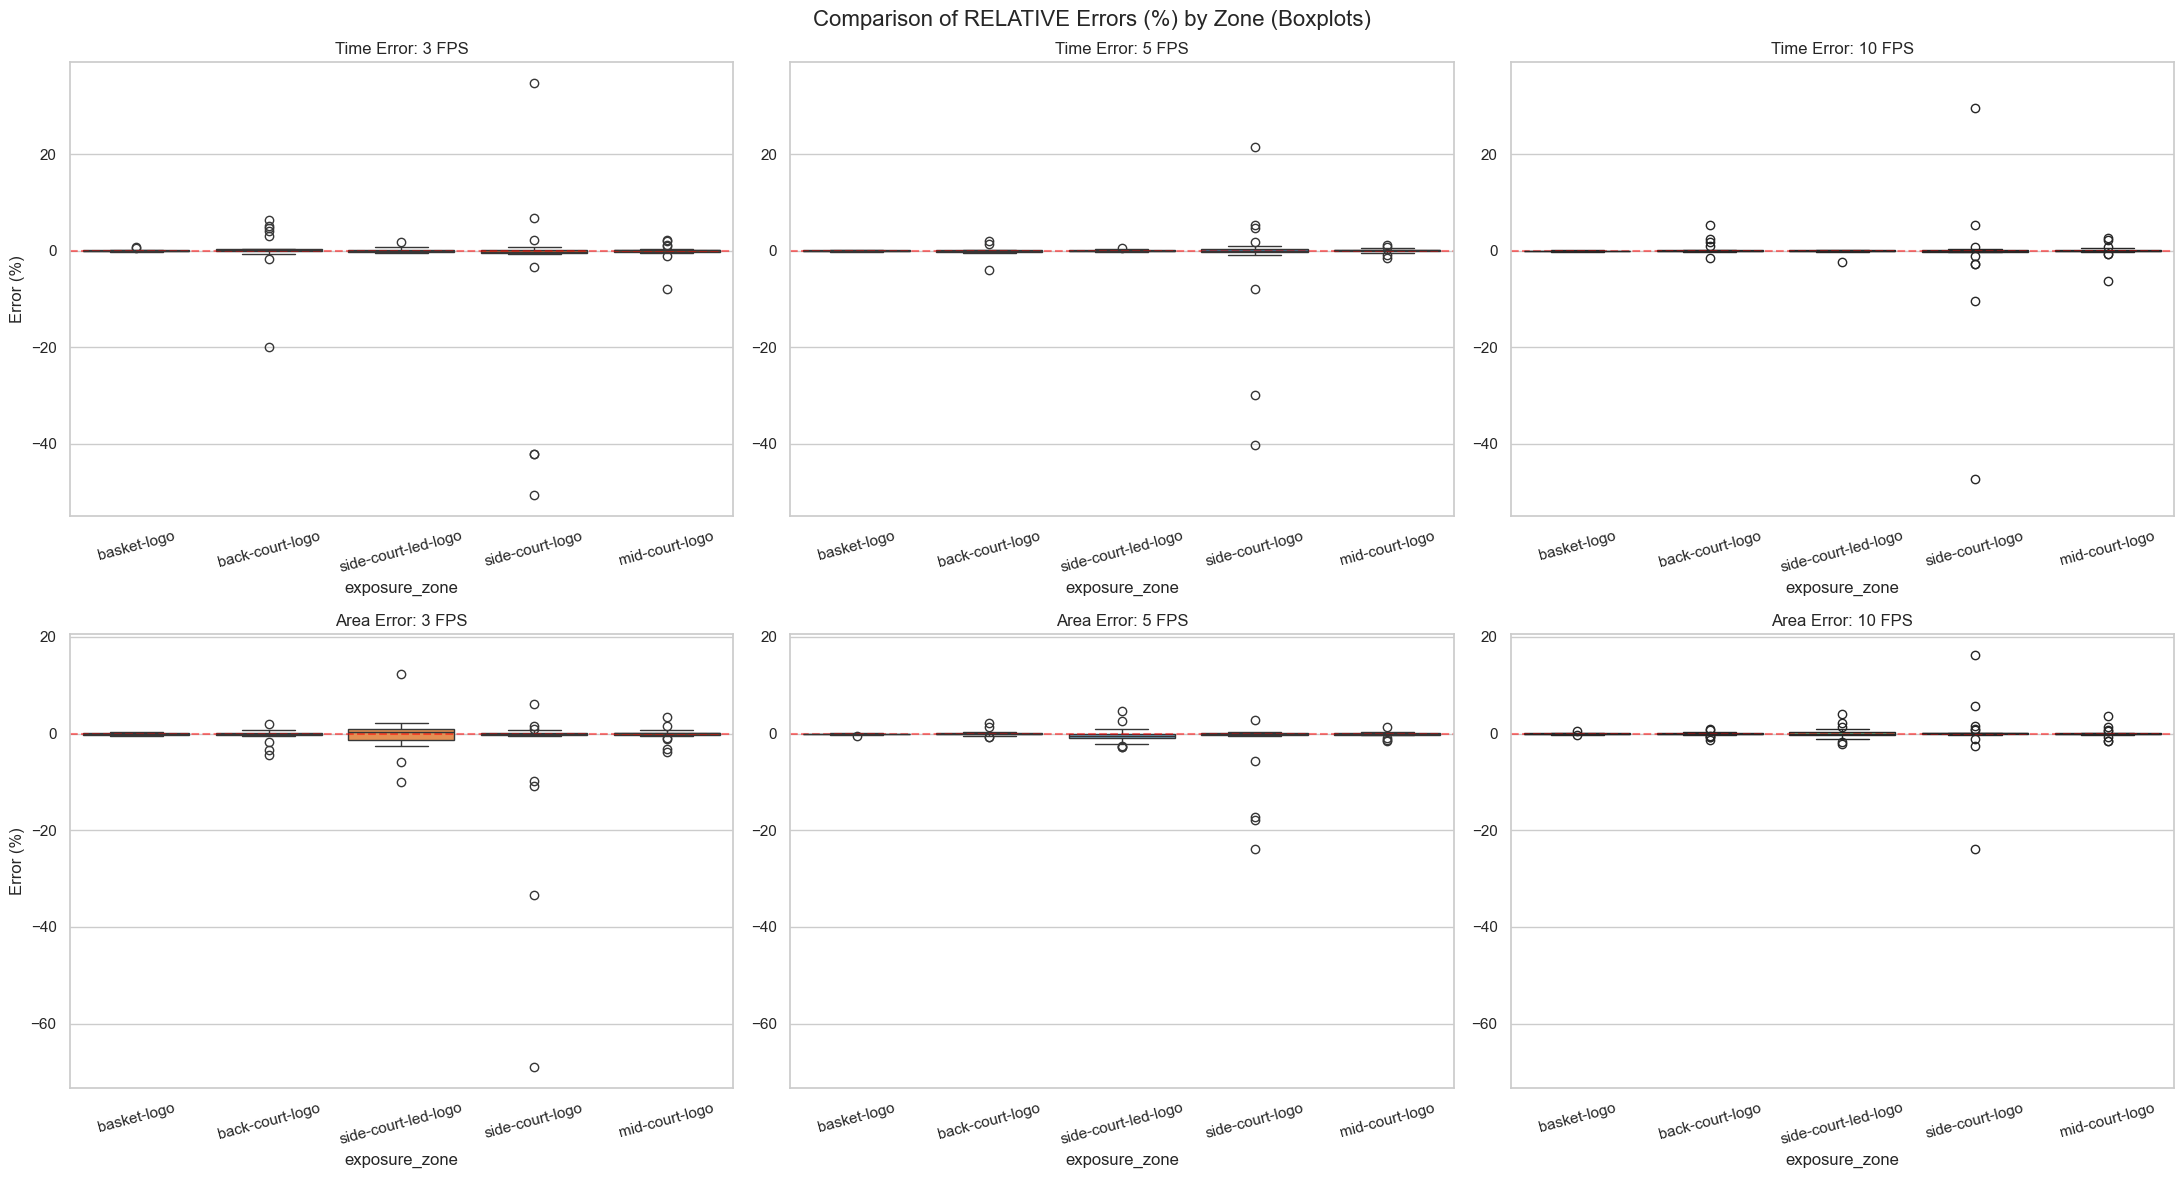

In [9]:
# 1. Calculation of common limits for the Y axis (including 3, 5 and 10 FPS)
# Time (%)
y_time_min = min(df_merge["exposure_time_pct_error_3"].min(), 
                 df_merge["exposure_time_pct_error_5"].min(), 
                 df_merge["exposure_time_pct_error_10"].min())

y_time_max = max(df_merge["exposure_time_pct_error_3"].max(), 
                 df_merge["exposure_time_pct_error_5"].max(), 
                 df_merge["exposure_time_pct_error_10"].max())

# 5% margin
y_time_lim = (y_time_min - (y_time_max-y_time_min)*0.05, y_time_max + (y_time_max-y_time_min)*0.05)

# Area (%)
y_area_min = min(df_merge["average_area_pct_error_3"].min(), 
                 df_merge["average_area_pct_error_5"].min(), 
                 df_merge["average_area_pct_error_10"].min())

y_area_max = max(df_merge["average_area_pct_error_3"].max(), 
                 df_merge["average_area_pct_error_5"].max(), 
                 df_merge["average_area_pct_error_10"].max())

# 5% margin
y_area_lim = (y_area_min - (y_area_max-y_area_min)*0.05, y_area_max + (y_area_max-y_area_min)*0.05)


# 2. Creation of the figure and axes (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle("Comparison of RELATIVE Errors (%) by Zone (Boxplots)", fontsize=16)

# --- Row 1: Exposure time (%) ---

# 3 FPS
sns.boxplot(data=df_merge, x='exposure_zone', y='exposure_time_pct_error_3', ax=axes[0, 0], palette="Oranges")
axes[0, 0].set_title("Time Error: 3 FPS")
axes[0, 0].set_ylabel("Error (%)")
axes[0, 0].set_ylim(y_time_lim) # Same scale
axes[0, 0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0, 0].tick_params(axis='x', rotation=15)

# 5 FPS
sns.boxplot(data=df_merge, x='exposure_zone', y='exposure_time_pct_error_5', ax=axes[0, 1], palette="Blues")
axes[0, 1].set_title("Time Error: 5 FPS")
axes[0, 1].set_ylabel("") # We hide the label
axes[0, 1].set_ylim(y_time_lim) # Same scale
axes[0, 1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0, 1].tick_params(axis='x', rotation=15)

# 10 FPS (NEW)
sns.boxplot(data=df_merge, x='exposure_zone', y='exposure_time_pct_error_10', ax=axes[0, 2], palette="Greens")
axes[0, 2].set_title("Time Error: 10 FPS")
axes[0, 2].set_ylabel("")
axes[0, 2].set_ylim(y_time_lim) # Same scale
axes[0, 2].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0, 2].tick_params(axis='x', rotation=15)


# --- Row 2: Average Area (%) ---

# 3 FPS
sns.boxplot(data=df_merge, x='exposure_zone', y='average_area_pct_error_3', ax=axes[1, 0], palette="Oranges")
axes[1, 0].set_title("Area Error: 3 FPS")
axes[1, 0].set_ylabel("Error (%)")
axes[1, 0].set_ylim(y_area_lim) # Same scale
axes[1, 0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1, 0].tick_params(axis='x', rotation=15)

# 5 FPS
sns.boxplot(data=df_merge, x='exposure_zone', y='average_area_pct_error_5', ax=axes[1, 1], palette="Blues")
axes[1, 1].set_title("Area Error: 5 FPS")
axes[1, 1].set_ylabel("")
axes[1, 1].set_ylim(y_area_lim) # Same scale
axes[1, 1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1, 1].tick_params(axis='x', rotation=15)

# 10 FPS (NEW)
sns.boxplot(data=df_merge, x='exposure_zone', y='average_area_pct_error_10', ax=axes[1, 2], palette="Greens")
axes[1, 2].set_title("Area Error: 10 FPS")
axes[1, 2].set_ylabel("")
axes[1, 2].set_ylim(y_area_lim) # Same scale
axes[1, 2].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1, 2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

C:\Users\Kyliv\AppData\Local\Temp\ipykernel_154688\564408171.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merge, x='exposure_zone', y='exposure_time_pct_error_3', ax=axes[0, 0], palette="Oranges")
C:\Users\Kyliv\AppData\Local\Temp\ipykernel_154688\564408171.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merge, x='exposure_zone', y='exposure_time_pct_error_5', ax=axes[0, 1], palette="Blues")
C:\Users\Kyliv\AppData\Local\Temp\ipykernel_154688\564408171.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_m

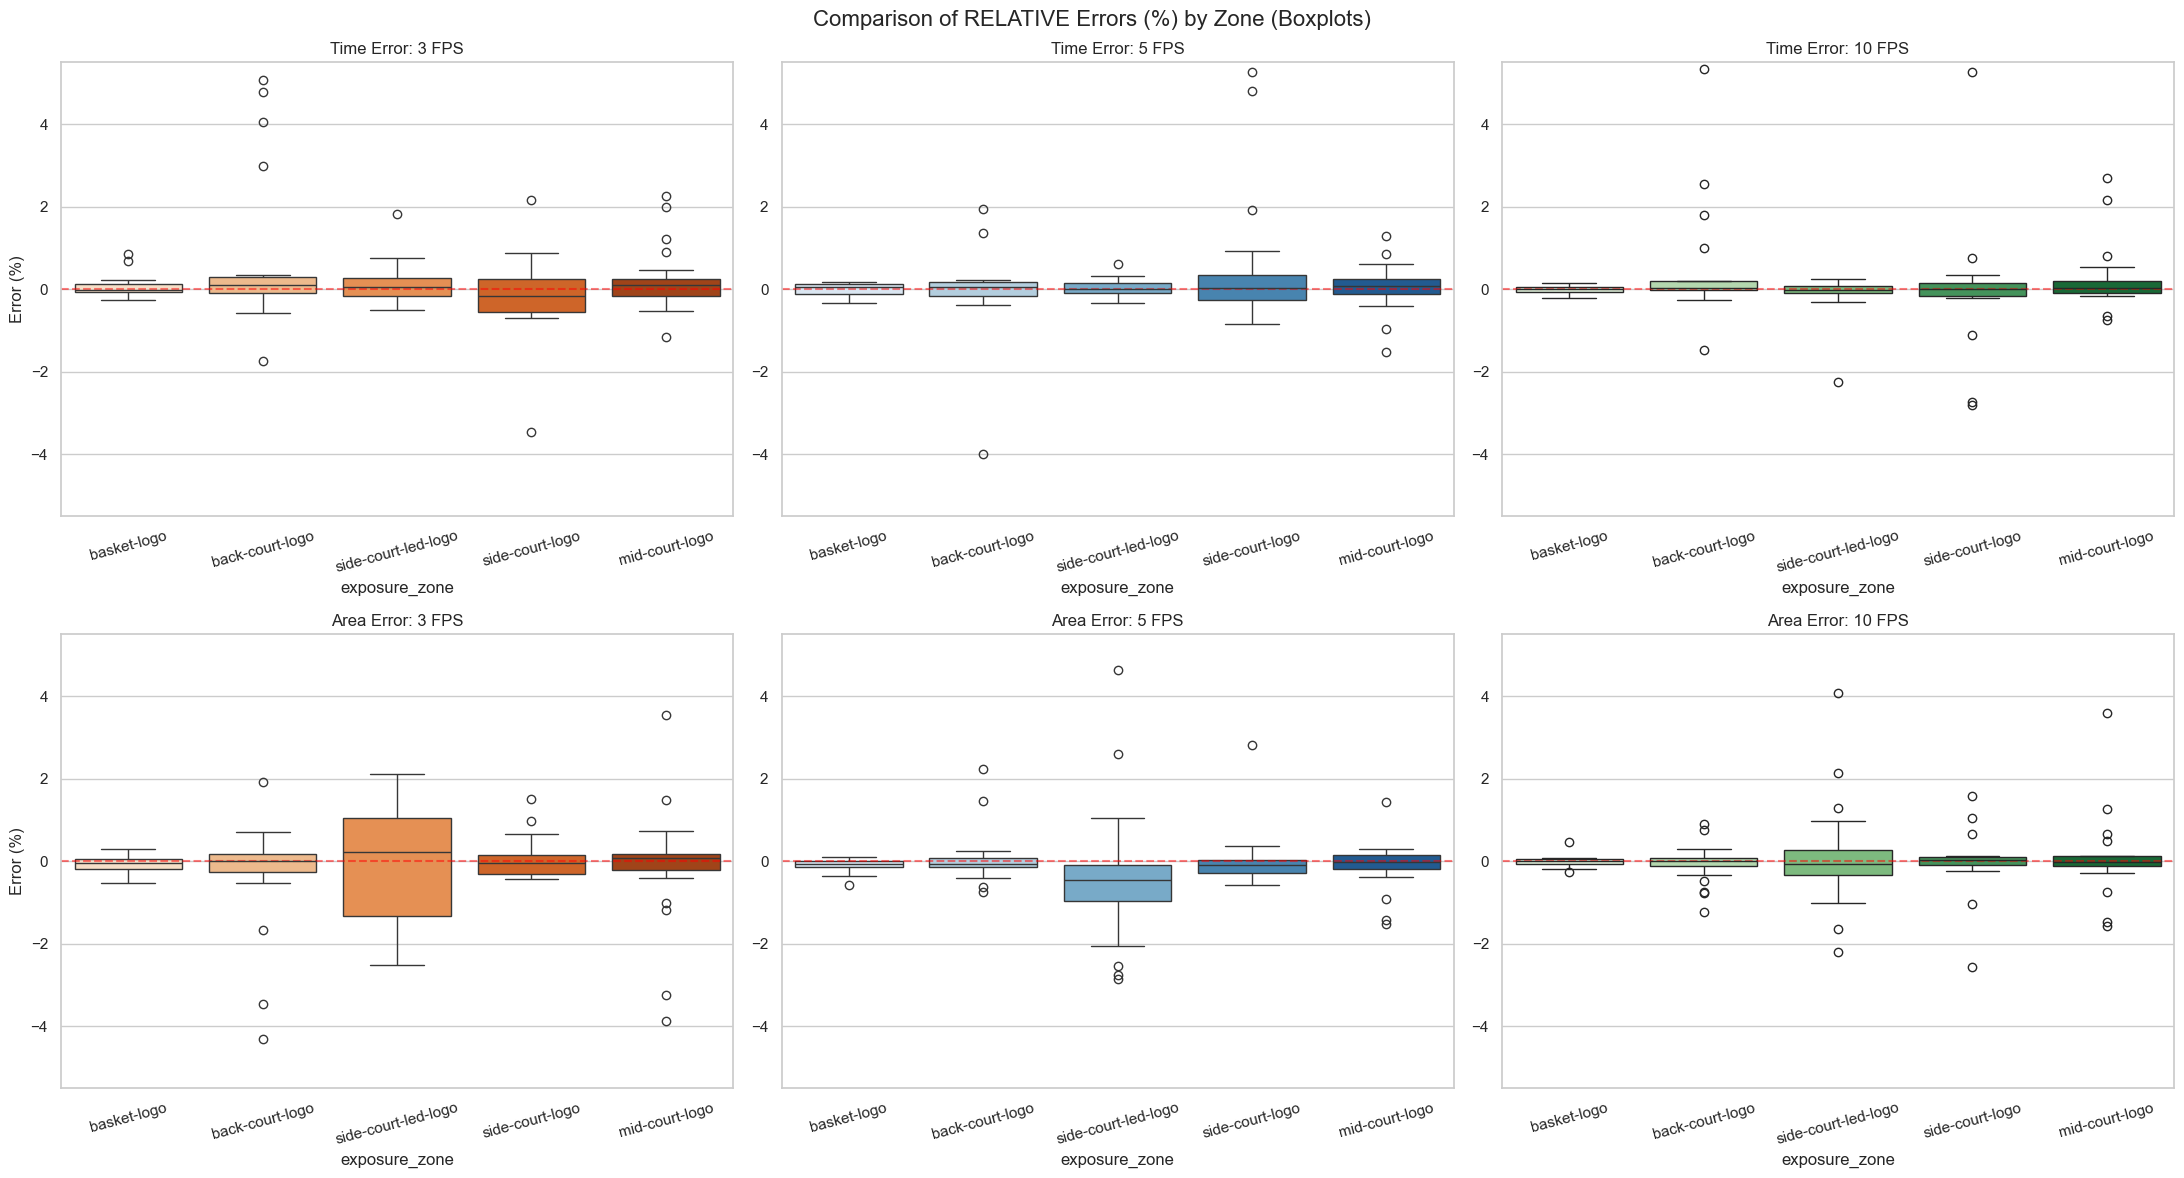

In [10]:
# 1. Calculation of common limits for the Y axis (including 3, 5 and 10 FPS)
# Time (%)
y_time_min = -5
y_time_max = 5

# 5% margin
y_time_lim = (y_time_min - (y_time_max-y_time_min)*0.05, y_time_max + (y_time_max-y_time_min)*0.05)

# Area (%)
y_area_min = -5
y_area_max = 5

# 5% margin
y_area_lim = (y_area_min - (y_area_max-y_area_min)*0.05, y_area_max + (y_area_max-y_area_min)*0.05)


# 2. Creation of the figure and axes (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle("Comparison of RELATIVE Errors (%) by Zone (Boxplots)", fontsize=16)

# --- Row 1: Exposure time (%) ---

# 3 FPS
sns.boxplot(data=df_merge, x='exposure_zone', y='exposure_time_pct_error_3', ax=axes[0, 0], palette="Oranges")
axes[0, 0].set_title("Time Error: 3 FPS")
axes[0, 0].set_ylabel("Error (%)")
axes[0, 0].set_ylim(y_time_lim) # Same scale
axes[0, 0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0, 0].tick_params(axis='x', rotation=15)

# 5 FPS
sns.boxplot(data=df_merge, x='exposure_zone', y='exposure_time_pct_error_5', ax=axes[0, 1], palette="Blues")
axes[0, 1].set_title("Time Error: 5 FPS")
axes[0, 1].set_ylabel("") # We hide the label
axes[0, 1].set_ylim(y_time_lim) # Same scale
axes[0, 1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0, 1].tick_params(axis='x', rotation=15)

# 10 FPS (NEW)
sns.boxplot(data=df_merge, x='exposure_zone', y='exposure_time_pct_error_10', ax=axes[0, 2], palette="Greens")
axes[0, 2].set_title("Time Error: 10 FPS")
axes[0, 2].set_ylabel("")
axes[0, 2].set_ylim(y_time_lim) # Same scale
axes[0, 2].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0, 2].tick_params(axis='x', rotation=15)


# --- Row 2: Average Area (%) ---

# 3 FPS
sns.boxplot(data=df_merge, x='exposure_zone', y='average_area_pct_error_3', ax=axes[1, 0], palette="Oranges")
axes[1, 0].set_title("Area Error: 3 FPS")
axes[1, 0].set_ylabel("Error (%)")
axes[1, 0].set_ylim(y_area_lim) # Same scale
axes[1, 0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1, 0].tick_params(axis='x', rotation=15)

# 5 FPS
sns.boxplot(data=df_merge, x='exposure_zone', y='average_area_pct_error_5', ax=axes[1, 1], palette="Blues")
axes[1, 1].set_title("Area Error: 5 FPS")
axes[1, 1].set_ylabel("")
axes[1, 1].set_ylim(y_area_lim) # Same scale
axes[1, 1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1, 1].tick_params(axis='x', rotation=15)

# 10 FPS (NEW)
sns.boxplot(data=df_merge, x='exposure_zone', y='average_area_pct_error_10', ax=axes[1, 2], palette="Greens")
axes[1, 2].set_title("Area Error: 10 FPS")
axes[1, 2].set_ylabel("")
axes[1, 2].set_ylim(y_area_lim) # Same scale
axes[1, 2].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1, 2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()